In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [18]:
df = pd.read_csv("shop_smart_ecommerce.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [19]:
X = df.drop(columns = ["Revenue"])
y = df["Revenue"].astype(int)

In [20]:
num_features = X.select_dtypes(include = ["int64", "float64"]).columns
cat_features = X.select_dtypes(include = ["object", "category"]).columns

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [47]:
dt = DecisionTreeClassifier(
    max_depth = 10,
    min_samples_leaf = 30,
    class_weight = "balanced",
    random_state = 42
)

In [48]:
pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", dt)
    ]
)

In [49]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=30,
                                        random_state=42))])

In [50]:
y_pred = pipe.predict(X_test)

print("F1_score: ", f1_score(y_test, y_pred))
print("ClassificationReport: ", classification_report(y_test, y_pred))
print("Confusion Matrix: ", confusion_matrix(y_test, y_pred))


F1_score:  0.6343434343434343
ClassificationReport:                precision    recall  f1-score   support

           0       0.96      0.86      0.91      2084
           1       0.52      0.82      0.63       382

    accuracy                           0.85      2466
   macro avg       0.74      0.84      0.77      2466
weighted avg       0.89      0.85      0.87      2466

Confusion Matrix:  [[1790  294]
 [  68  314]]


# Hyperparameter Tuning

In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth": [4,6,8,10,12],
    "model__min_samples_leaf": [10,20,30,40],
    "model__min_samples_split": [2,5,10,20],
    "model__criterion": ["gini","entropy"]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring= "f1",
    cv = 5,
    n_jobs = -1
)

grid.fit(X_train, y_train)

print("Best F1: ", grid.best_score_)
print("Best params: ", grid.best_params_)

Best F1:  0.6415654086422439
Best params:  {'model__criterion': 'entropy', 'model__max_depth': 4, 'model__min_samples_leaf': 30, 'model__min_samples_split': 2}


# Report Visualization

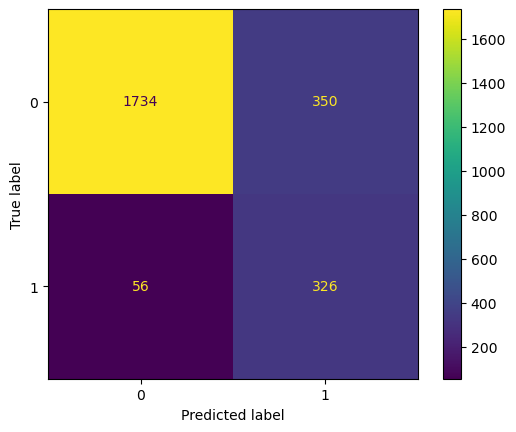

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(grid.best_estimator_, X_test, y_test)

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.85      0.90      2084
           1       0.50      0.83      0.63       382

    accuracy                           0.85      2466
   macro avg       0.73      0.84      0.77      2466
weighted avg       0.89      0.85      0.86      2466



In [41]:
feature_names = grid.best_estimator_.named_steps["preprocess"].get_feature_names_out()

importance = grid.best_estimator_.named_steps["model"].feature_importances_

pd.Series(importance, index=feature_names).sort_values(ascending=False).head(10)

num__PageValues                 0.763946
cat__Month_Nov                  0.093147
cat__Month_May                  0.040176
cat__Month_Mar                  0.036873
num__BounceRates                0.025763
num__ProductRelated_Duration    0.018840
num__ExitRates                  0.012811
num__ProductRelated             0.005143
num__Administrative             0.003302
num__Informational              0.000000
dtype: float64

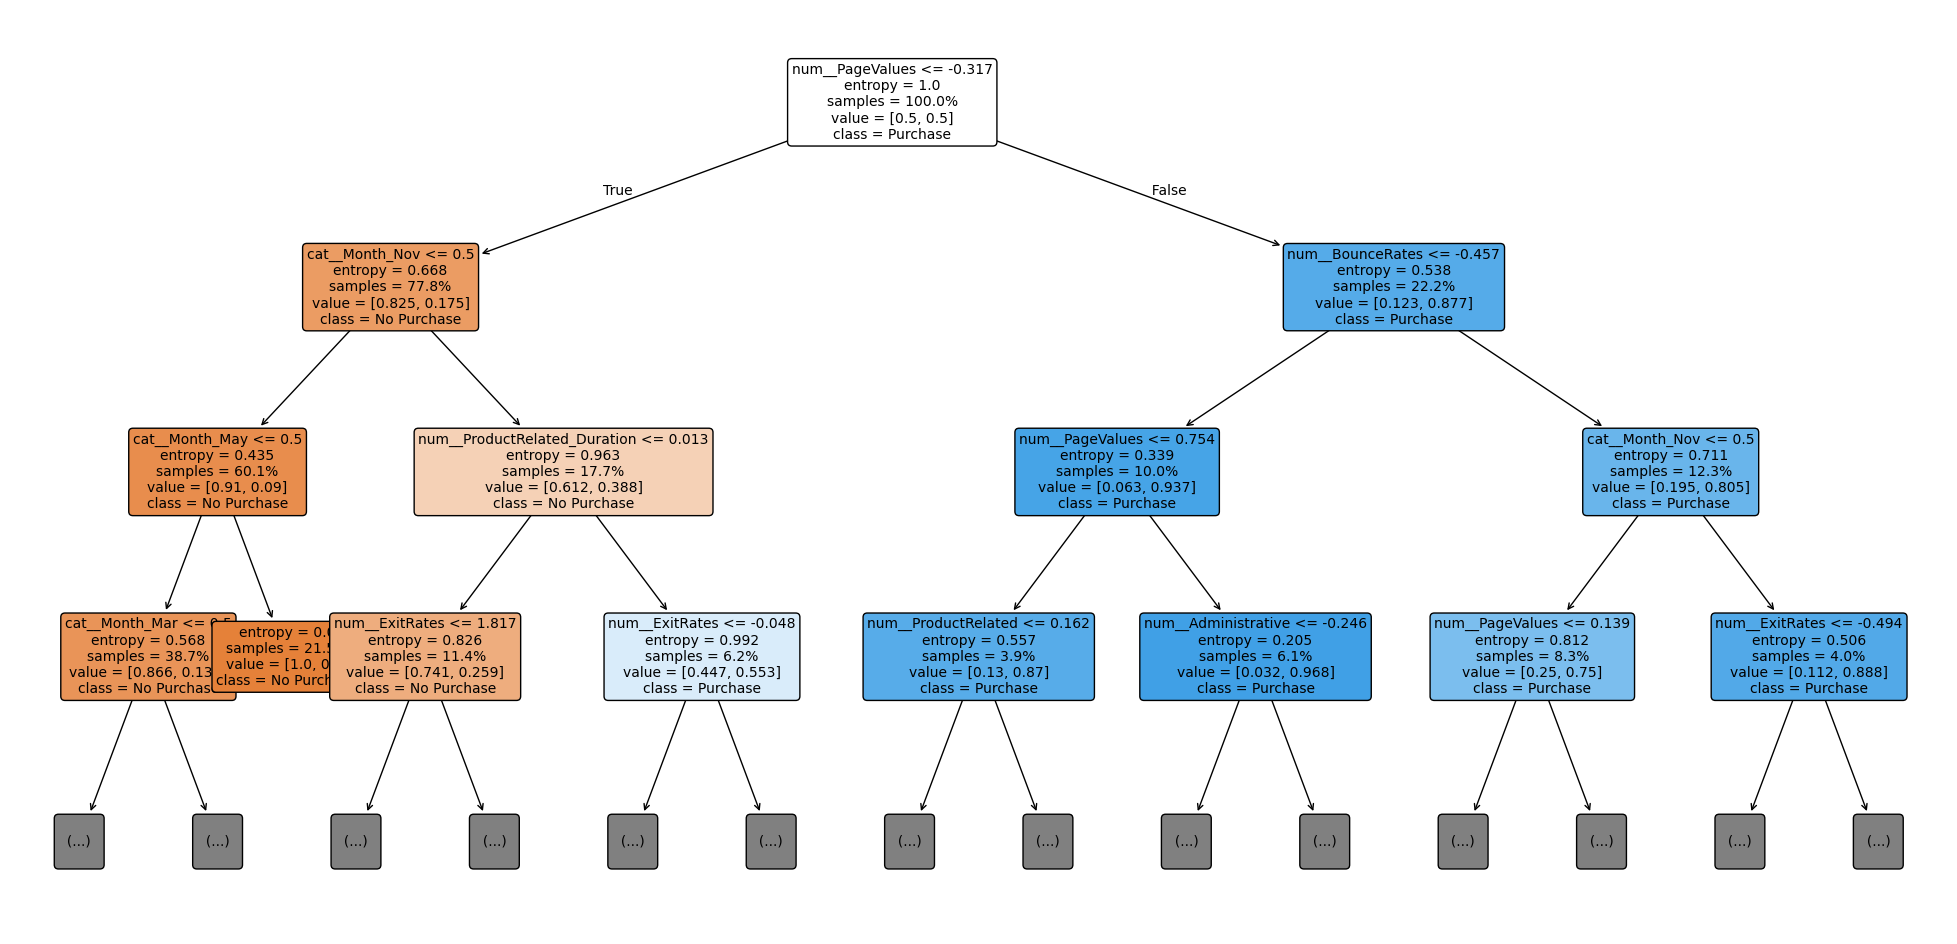

In [42]:
feature_names = grid.best_estimator_.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(25,12))

plot_tree(
    grid.best_estimator_.named_steps["model"],
    feature_names=feature_names,
    class_names=["No Purchase","Purchase"],
    filled=True,
    rounded=True,
    proportion=True,
    max_depth=3,
    fontsize=10
)

plt.show()